<a href="https://colab.research.google.com/github/larislima11/CASE_ML_MARKETING_VENDAS_ESTOQUE/blob/main/CASE_MACHINE_LEARNING_INVESTIMENTO_ESTOQUE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

USANDO ML PARA ESTIMAR A VENDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# "VAMOS INVESTIR EM 75K EM MARKETING, QUAL DEVE SER O ESTOQUE ENVIADO PARA A LOJA?"

In [ ]:
# IMPORTANDO A BASE DE VENDAS - VARIAVEIS DA BASE DADA PELO CLIENTE (ARQUIVO XSLS)
# RELACIONAMENTO LINEAR ENTRE AS DUAS VARIAVEIS: QUANTO MAIS INVESTIMENTO EM MARKETING, MAIS VENDAS (AUMENTO PROPORCIONAL)
# OBJETIVO: ENCONTRAR A MEHOR RETA (MENOR ERRO PADRÃO) ENTRE INVESTIMENTO EM MARKETING E QUANTIDADE DE VENDAS (ESTOQUE)

base = pd.read_excel("Investimento_x_Venda.xlsx")
base.head()

,Investimento em marketing,Venda Qtd
0,20,118
1,25,142
2,40,225
3,52,260
4,67,295


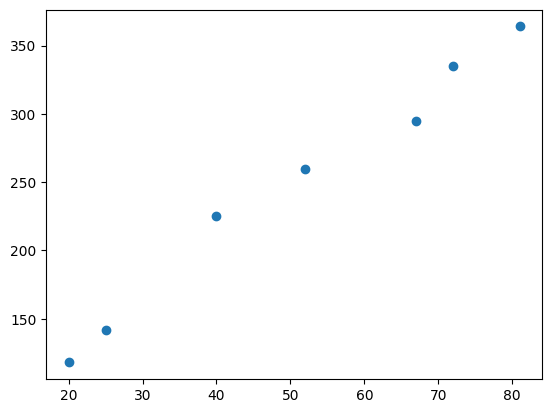

In [ ]:
plt.scatter(base["Investimento em marketing"], base["Venda Qtd"])
plt.show()

GRÁFICO RELAÇÃO LINEAR: QUANTO MAIS INVESTIMENTO EM MARKETING = MAIS VENDAS.





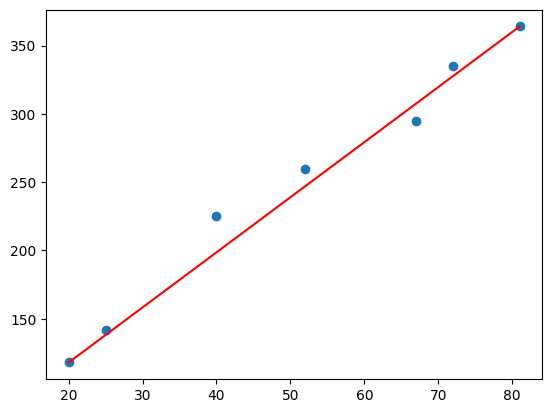

In [ ]:
plt.scatter(base["Investimento em marketing"], base ["Venda Qtd"])
x0 = base["Investimento em marketing"] [0]
y0 = base["Venda Qtd"] [0]
x1 = base["Investimento em marketing"] [6]
y1 = base["Venda Qtd"] [6]
plt.plot([x0, x1], [y0, y1], "r")
plt.show()

EXEMPLO:
# USANDO A EQUEÇÃO (FUNÇÃO) DA RETA PARA DETERMINAR A VENDA
**y + ax+b**

* criando função
* parâmetros
* irá **return** valor necessário de estoque após investiento de 75k em marketing
* sem ML = mais dificuldade em encontrar o valor com menor erro padrão


In [ ]:
def EncontraY(x_reta, y_reta, x):
  a = (y_reta[1] - y_reta[0]) / (x_reta[1] - x_reta[0])
  b = y_reta[0] - a * x_reta[0]
  y = a * x + b
  return y

In [ ]:
EncontraY([x0, x1], [y0, y1], 75)

np.float64(339.8032786885246)

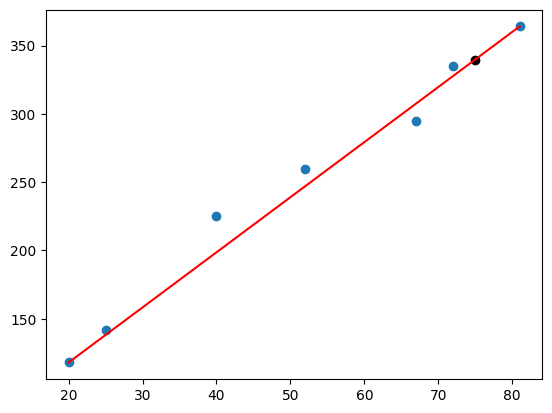

In [ ]:
plt.scatter(base["Investimento em marketing"], base["Venda Qtd"])
plt.scatter(75, EncontraY([x0, x1], [y0, y1], 75), color="k")
x0 = base ["Investimento em marketing"] [0]
y0 = base ["Venda Qtd"] [0]
x1 = base ["Investimento em marketing"] [6]
y1 = base ["Venda Qtd"] [6]
plt.plot([x0,x1],[y0,y1], "r")
plt.show()

 PONTO DA RETA(X,Y): REGRESSÃO LINEAR através da função/equeção.
 * VALOR ESTIMADO

# DESCOBRINDO A VENDA USANDO MACHINE LEARNING

USANDO A BIBLIOTECA EM PYTHON SKLEARN (MACHINE LEARNING & REGRESSÃO LINEAR)

In [ ]:
from sklearn import linear_model

In [ ]:
reg = linear_model.LinearRegression()

In [ ]:
reg.fit(base["Investimento em marketing"].values.reshape(-1,1), base["Venda Qtd"])

LinearRegression()

In [ ]:
reg.coef_

array([3.90643623])

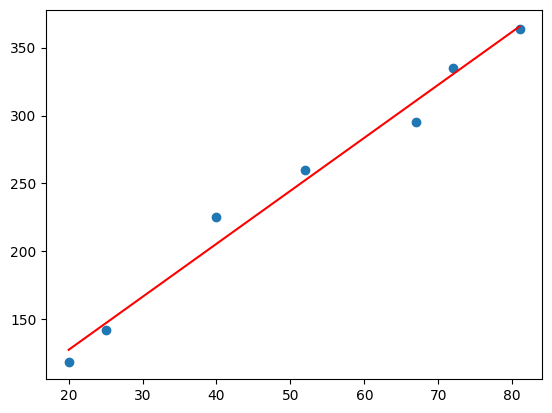

In [ ]:
plt.scatter(base["Investimento em marketing"], base["Venda Qtd"])
x = np.array(base["Investimento em marketing"])
y = reg.intercept_ + x*reg.coef_
plt.plot(x,y,"r")
plt.show()

In [ ]:
reg.predict([[75]])

array([342.18304104])

# GRÁFICO: RETA MAIS PRECISA CRIADA PELO MEU MODELO DE MACHINE LEARNING COM REGRESSÃO LINEAR (MENOR ERRO PADRÃO)  

# RESPOSTA VALOR ESTIMADO: 342.183,000

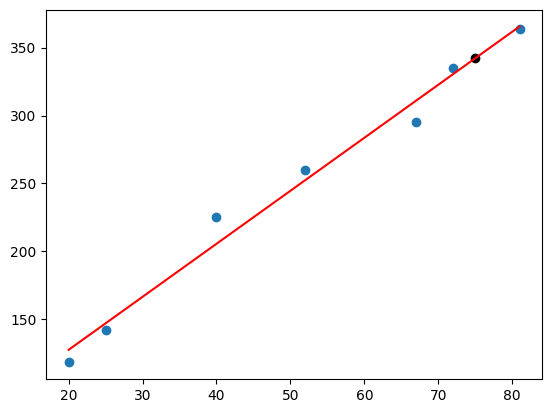

In [ ]:
plt.scatter(base["Investimento em marketing"], base["Venda Qtd"])
plt.scatter(75, reg.predict([[75]])[0], color="k")
x = np.array(base["Investimento em marketing"])
y = reg.intercept_ + x*reg.coef_
plt.plot(x,y,"r")
plt.show()
